# Lab 1, Core A: Least squares, conditioning, and $QR$
### <div align="right"> Linear Algebra for Data Science, MSc DS &mdash; UCU APPS </div>
### <div align="right"> adapted from a 2022 assignment by Ostap Dyhdalovych and Volodymyr Kuchynskyi </div>

## Completed by:
*   Bohdan Prokhorov
*   Markiian Yatsyshyn


### What this core is about

Fitting a model to data is a least squares problem, and you have seen the formula. This
notebook is about the gap between the formula and an algorithm: **the same mathematics,
implemented two ways, stops agreeing** once the problem is hard enough, and one of the two
ways is wrong long before it looks wrong.

You will fit a trend-plus-seasonality model to 166 years of monthly temperature readings,
raise the complexity of the model until your two solvers disagree, and find out which one
to believe and why.

### Marking

This is **Core A** of Lab 1. The lab is worth 6 points: 2 for this core, 2 for Core B
(the DFT), 1 for the code, and up to 1 for extensions. Core marks are awarded at the
**oral defence**, not from the notebook alone, so a correct result you cannot explain is
worth less than a partial result you understand. Individual cells carry no separate marks.

**Bonus.** The three extensions are the only route to the bonus point. They are marked
$\star$ and sit at the **end** of the notebook they build on: Extensions 1 and 2 at the end
of this one, Extension 3 at the end of Core B. Attempt at most one; a second earns nothing.

Questions marked *harder &mdash; not required* go beyond the course material. They earn no
extra points, are marked generously, and are there to be discussed at the defence.

### Ground rules

* Sections 1-4: implement the linear algebra yourself with basic `numpy`. You may use
  `np.linalg.qr`, `np.linalg.solve`, `np.linalg.cond` and `np.linalg.norm`.
* Always write `np.linalg.qr(A, mode="reduced")` with the mode given **explicitly**.
  The default has not been stable across numpy versions, and `mode="complete"` returns
  an $m \times m$ matrix $Q$ that does not fit the formulas used here.
* **`np.linalg.inv` is forbidden throughout.** If you find yourself wanting it, that is
  the notebook working as intended &mdash; see Question 1.1.
* `np.linalg.lstsq` is allowed **only** where explicitly asked for, as a reference answer.
* Where a cell asks you to *predict* before computing, write the prediction down first.
  A prediction written after the fact teaches nothing, and the defence will ask.


In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
import pandas as pd

np.set_printoptions(precision=4, suppress=False)

DATA_FILE = "land-temp-1850-2015.csv"   # supplied with the lab

# Report your environment. The last digits in section 3 depend on the
# LAPACK build behind numpy, so two machines can legitimately differ.
print("numpy", np.__version__, "| pandas", pd.__version__, "| python 3.14")


numpy 2.5.3 | pandas 3.0.6 | python 3.14


---
## 0. The data

Average monthly temperatures, January 1850 to December 2015: 1992 readings, no gaps.

### Where this comes from, and what it is

This is the `LandAverageTemperature` column of `GlobalTemperatures.csv` from the Berkeley
Earth *Climate Change: Earth Surface Temperature Data* collection, distributed on Kaggle
under CC BY-NC-SA 4.0. Berkeley Earth builds it by combining roughly 1.6 billion
temperature reports from 16 pre-existing archives, including NOAA's MLOST, NASA's GISTEMP
and the UK's HadCRUT.

Four things about it are worth knowing **before** you model it:

1. **It is a global land average, not a place.** One number per month for the entire land
   surface of the Earth. There is no city, country or station to reason about, and no
   local conclusion to draw.
2. **The seasonal swing is the Northern Hemisphere's**, because that is where most of the
   land is. The two hemispheres' summers do not cancel; the larger one wins.
3. **The series starts in 1750, and we use it from 1850.** That is not arbitrary. The
   original column has twelve missing months scattered through 1750-1752, and the early
   record carries much larger stated uncertainties. Berkeley Earth's own maximum, minimum
   and land-and-ocean columns all begin in 1850 for the same reason. Restricting to 1850
   buys a series with **no gaps and uniform monthly spacing** &mdash; which Core B needs
   absolutely, since a transform has no way to represent a month that is not there.
4. **Every value is an estimate with an error bar.** The file ships a companion
   `LandAverageTemperatureUncertainty` column, a 95% confidence half-width, which is large
   early and small late. Ordinary least squares assumes all observations are equally
   trustworthy. That assumption is false here, and one of the extension tasks is about
   what to do instead.


In [2]:
temp_data = pd.read_csv(DATA_FILE)
temp_data["date"] = pd.to_datetime(temp_data["date"])

N = temp_data.shape[0]
y = temp_data["avg_temp"].to_numpy()

# The time index is FLOAT, and that is not cosmetic. np.arange(N) gives
# int64, and t**k for k >= 6 then silently wraps around: at degree 10 the
# last entry comes out negative. numpy issues no warning. Integer overflow
# is not one of the failure modes this notebook is about -- keep it out.
t_month = np.arange(N, dtype=float)         # 0.0, 1.0, ..., N-1

print(f"N = {N} readings, {temp_data['date'].min():%Y-%m} to {temp_data['date'].max():%Y-%m}")
print(f"missing values: {temp_data.isna().sum().sum()}")
temp_data.describe()


N = 1992 readings, 1850-01 to 2015-12
missing values: 0


,date,avg_temp
count,1992,1992.000000
mean,1932-12-16 00:11:33.975904,8.571583
min,1850-01-01 00:00:00,0.404000
25%,1891-06-23 12:00:00,4.430000
50%,1932-12-16 12:00:00,8.850500
75%,1974-06-08 12:00:00,12.858500
max,2015-12-01 00:00:00,15.482000
std,NaN,4.263193


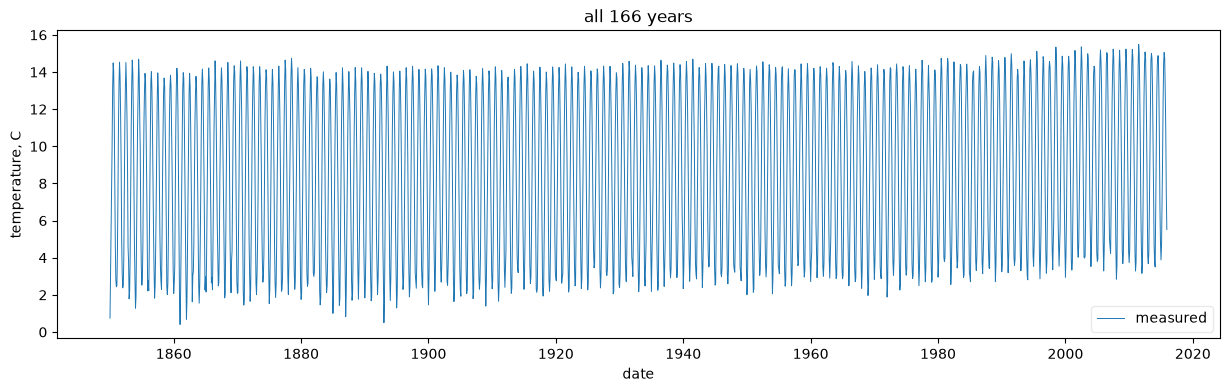

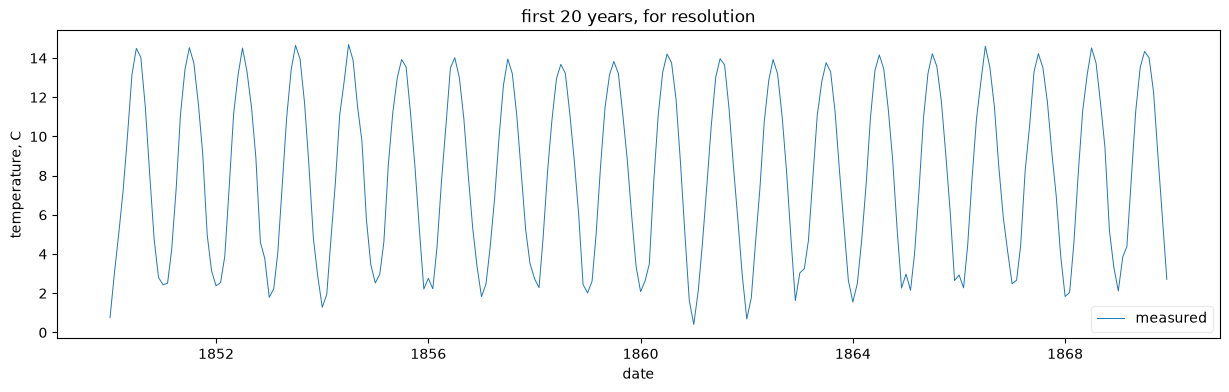

In [3]:
def plot_temps(time, data, prediction=None, title=None):
    plt.figure(figsize=(15, 4))
    plt.plot(time, data, lw=0.7, label="measured")
    if prediction is not None:
        plt.plot(time, prediction, lw=1.2, label="model")
    plt.xlabel("date"); plt.ylabel("temperature, C")
    if title: plt.title(title)
    plt.legend(framealpha=0.4); plt.show()


def RMSE(predicted, reference):
    return np.sqrt(np.mean((predicted - reference) ** 2))


plot_temps(temp_data["date"], y, title="all 166 years")
plot_temps(temp_data["date"][:240], y[:240], title="first 20 years, for resolution")


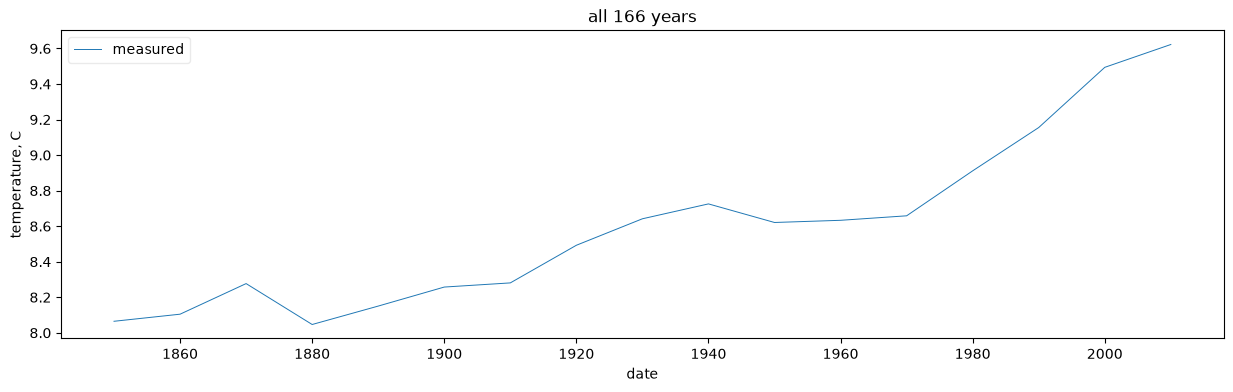

In [4]:
temp_data_grouped_by_decade = temp_data.groupby(temp_data['date'].dt.year // 10 * 10)['avg_temp'].mean().reset_index(name='avg_temp')

plot_temps(temp_data_grouped_by_decade["date"], temp_data_grouped_by_decade['avg_temp'], title="all 166 years")

### **0.1** What do you see?

Describe the series in two or three sentences: what varies fast, what varies slowly, and
roughly how large each is. You will build a model with one term for each.

---
\### I see time-series data with a strong seasonal cycle that repeats yearly and varies fast, oscillating between 2 and 14 degrees. I can also see a weak trend that varies slowly and increases over time, by about 1.5 degrees across the 166 years, that is what we can see if group the temp data by decade and plot the trend only  \###

---


---
## 1. Three routes to the same solution

For a design matrix $A$ with linearly independent columns and a data vector $\mathbf{y}$,
the least squares solution $\hat{\mathbf{x}} = \arg\min \|A\mathbf{x} - \mathbf{y}\|$ is
characterised by the residual being orthogonal to $\mathbf{Col}(A)$, equivalently by the
**normal equation**
$$ A^{\top}A\,\hat{\mathbf{x}} = A^{\top}\mathbf{y}. $$
Using the reduced factorization $A = QR$ with $Q^\top Q = I$, the same solution satisfies
$$ R\,\hat{\mathbf{x}} = Q^{\top}\mathbf{y}, $$
an upper-triangular system. These two are **equivalent in exact arithmetic** &mdash; you proved
this in the tutorial. You will now implement both and find out what that equivalence is
worth in floating point.


### **1.1** Why is `inv` forbidden?

The textbook formula is $\hat{\mathbf{x}} = (A^{\top}A)^{-1}A^{\top}\mathbf{y}$, and it is
correct. Give **two separate reasons** &mdash; one about cost, one about accuracy &mdash; why no
library computes it that way. Then state what is computed instead.

---
1. If we talk about the accuracy, every matrix has a condition number, and forming A^T @ A squares it (cond(A^T @ A) == cond(A)^2). This is where we lose significant digits, because a computer stores floats with only about 16 digits of precision. Squaring the condition number doubles the loss, and the result may no longer fit into the precision we have. QR is applied tries to fix it by avoiding this situation for any matrix.
2. To find the inverse you should perform Gaussian elimination that in the worst case can be done with O(n^3) complexity, but we can omit this by solving the system directly using $A^{\top}A\,\hat{\mathbf{x}} = A^{\top}\mathbf{y}.$

---


In [5]:
def solve_normal_equation(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the normal equation.

    Form the matrix A^T A and the vector A^T y, then solve the resulting
    square system. Do NOT invert anything: np.linalg.solve takes a system,
    not an inverse.

    Args:
        A: (m, n) design matrix, m > n, independent columns
        y: (m,) data vector
    Returns:
        (n,) coefficient vector
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    coeffs = np.linalg.solve(A.T @ A, A.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


In [6]:
def back_substitution(R: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Solve R x = b for upper-triangular R, by hand.

    Work from the last row upwards. Do not call np.linalg.solve here: the
    point is that this costs O(n^2), not O(n^3), and you should see why.
    """
    n = R.shape[0]
    x = np.zeros(n)
    # ========= YOUR CODE STARTS HERE ========= #
    for i in range(n - 1, -1, -1):
        x[i] = (b[i] - np.sum(R[i, i + 1:] * x[i + 1:])) / R[i, i]
    # ========== YOUR CODE ENDS HERE ========== #
    return x


def solve_qr(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Least squares via the reduced QR factorization.

    Use np.linalg.qr(A, mode='reduced') to get Q and R, then solve
    -- pass mode explicitly, never rely on the default -- and then solve
    R x = Q^T y with your back_substitution. A^T A must never be formed.
    """
    assert A.ndim == 2 and y.ndim == 1 and A.shape[0] == y.shape[0]

    # ========= YOUR CODE STARTS HERE ========= #
    Q, R = np.linalg.qr(A, mode='reduced')
    coeffs = back_substitution(R, Q.T @ y)
    # ========== YOUR CODE ENDS HERE ========== #
    return coeffs


def solve_reference(A: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Trusted reference. This is the only sanctioned use of lstsq."""
    return np.linalg.lstsq(A, y, rcond=None)[0]


In [7]:
def test_solvers():
    rng = np.random.default_rng(0)
    A = rng.standard_normal((40, 4))          # well conditioned by construction
    x_true = np.array([1.0, -2.0, 0.5, 3.0])
    y_ = A @ x_true + 0.01 * rng.standard_normal(40)

    xn, xq, xr = solve_normal_equation(A, y_), solve_qr(A, y_), solve_reference(A, y_)
    for name, x in (("normal equation", xn), ("QR", xq)):
        assert isinstance(x, np.ndarray), f"{name}: not implemented yet"
        assert np.allclose(x, xr, atol=1e-10), f"{name} disagrees with the reference"
    print(f"cond(A) = {np.linalg.cond(A):.2e}")
    print("TEST 1: SUCCESS -- all three routes agree on an easy problem")

test_solvers()


cond(A) = 1.49e+00
TEST 1: SUCCESS -- all three routes agree on an easy problem


### **1.2** Residual orthogonality

Take the fit from the test above and verify numerically that the residual
$\mathbf{r} = \mathbf{y} - A\hat{\mathbf{x}}$ is orthogonal to every column of $A$.
Report $\|A^{\top}\mathbf{r}\|$ and say what value would count as "zero" here, and why it
is not exactly zero.

Then verify Pythagoras: $\|\mathbf{y}\|^2 = \|A\hat{\mathbf{x}}\|^2 + \|\mathbf{r}\|^2$.


In [8]:
# ========= YOUR CODE STARTS HERE ========= #
rng = np.random.default_rng(0)
A = rng.standard_normal((40, 4))
x_true = np.array([1.0, -2.0, 0.5, 3.0])
y_ = A @ x_true + 0.01 * rng.standard_normal(40)

x_hat = solve_qr(A, y_)
r = y_ - A @ x_hat

eps = np.finfo(A.dtype).eps
tol = max(A.shape) * eps * np.linalg.norm(A, 2) * np.linalg.norm(y_)

orth = np.linalg.norm(A.T @ r)
lhs = np.linalg.norm(y_) ** 2
rhs = np.linalg.norm(A @ x_hat) ** 2 + np.linalg.norm(r) ** 2

print(f"||A^T r||        = {orth:.3e}")
print(f"tolerance        = {tol:.3e}")
print(f"orthogonal       = {orth <= tol}")
print(f"relative gap     = {abs(lhs - rhs) / lhs:.3e}")
print(f"pythagoras holds = {np.isclose(lhs, rhs, rtol=10 * eps, atol=0)}")
print(f"||x_hat - lstsq|| = {np.linalg.norm(x_hat - np.linalg.lstsq(A, y_, rcond=None)[0]):.3e}")

# ========== YOUR CODE ENDS HERE ========== #


||A^T r||        = 4.417e-14
tolerance        = 1.465e-12
orthogonal       = True
relative gap     = 2.306e-16
pythagoras holds = True
||x_hat - lstsq|| = 3.168e-15


---
We computed the norm of A.T @ r and got a number smaller than the numerical tolerance, which is calculated as max(m, n) * eps * norm(A, 2) * norm(y). Everything below this tolerance is treated as zero. The tolerance is not a fixed constant because rounding error grows with the size of the matrix and the magnitude of its values, so it has to be scaled to each problem. The norm is not exactly zero because all values are stored in double precision, which has limited accuracy, so every operation adds a small rounding error so we will never reach "perfect" orthogonality.

---


---
## 2. A model for monthly temperature

The series has a slow component and a fast one. Model the slow part by a polynomial in
time and the fast part by one pair of trigonometric functions at the annual period
$T = 12$ months:
$$ F(t) \;=\; \underbrace{a_0 + a_1 t + \dots + a_d t^{d}}_{\text{trend, degree } d}
\;+\; \underbrace{b_1\cos\frac{2\pi t}{T} + b_2\sin\frac{2\pi t}{T}}_{\text{seasonality}}. $$

This is still **linear least squares**: $F$ is non-linear in $t$ but linear in the
unknowns $a_0,\dots,a_d,b_1,b_2$, and that is all the method requires. Each basis
function becomes one column of $A$.


### **2.1** Build the design matrix

Note the `t` argument: it is the time variable *as you choose to measure it*. That
choice looks cosmetic. Section 4 is about how badly it is not.


In [9]:
def design_matrix(t: np.ndarray, degree: int, period: float = 12.0,
                  seasonal: bool = True,
                  month_index: np.ndarray = None) -> np.ndarray:
    """Columns: 1, t, t^2, ..., t^degree, then optionally cos and sin.

    Args:
        t:           time variable for the POLYNOMIAL columns, in whatever
                     units you choose. Pass a float array.
        month_index: time variable for the SEASONAL columns, which must stay
                     in months whatever you do to `t` -- the period is 12
                     months and rescaling `t` must not silently rescale it.
                     Defaults to 0, 1, ..., len(t)-1.

    Returns:
        (len(t), degree + 1 + 2*seasonal) design matrix
    """
    t = np.asarray(t, dtype=float)
    if month_index is None:
        month_index = np.arange(t.shape[0], dtype=float)

    # ========= YOUR CODE STARTS HERE ========= #
    A = np.vander(t, N=degree + 1, increasing=True)
    if seasonal:
        w = 2 * np.pi * month_index / period
        A = np.column_stack([A, np.cos(w), np.sin(w)])
    # ========== YOUR CODE ENDS HERE ========== #
    return A


def test_design_matrix():
    A = design_matrix(np.arange(24, dtype=float), degree=2)
    assert A.shape == (24, 5), f"expected (24, 5), got {A.shape}"
    assert np.allclose(A[:, 0], 1.0), "first column should be the constant term"
    assert np.allclose(A[:, 1], np.arange(24)), "second column should be t"

    # rescaling t must NOT change the seasonal columns
    B = design_matrix(np.linspace(0, 1, 24), degree=2,
                      month_index=np.arange(24, dtype=float))
    assert np.allclose(A[:, -2:], B[:, -2:]), "seasonal columns moved when t was rescaled"
    print("TEST 2: SUCCESS")

test_design_matrix()


TEST 2: SUCCESS


### **2.2** Fit the linear-trend model and look at it

Fit with `degree=1` on the raw month index, using **any** of your three solvers, and plot.
Report the RMSE, and report the trend coefficient in degrees per century &mdash; a number a
non-mathematician could be told.


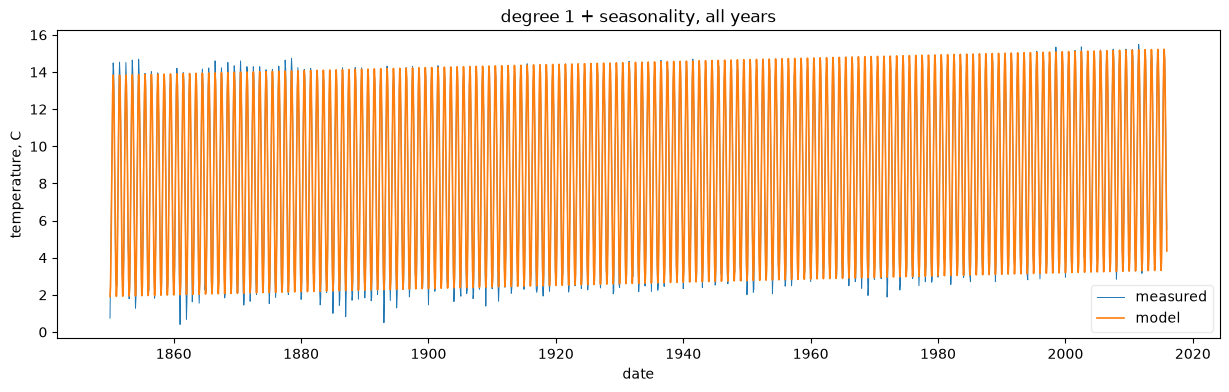

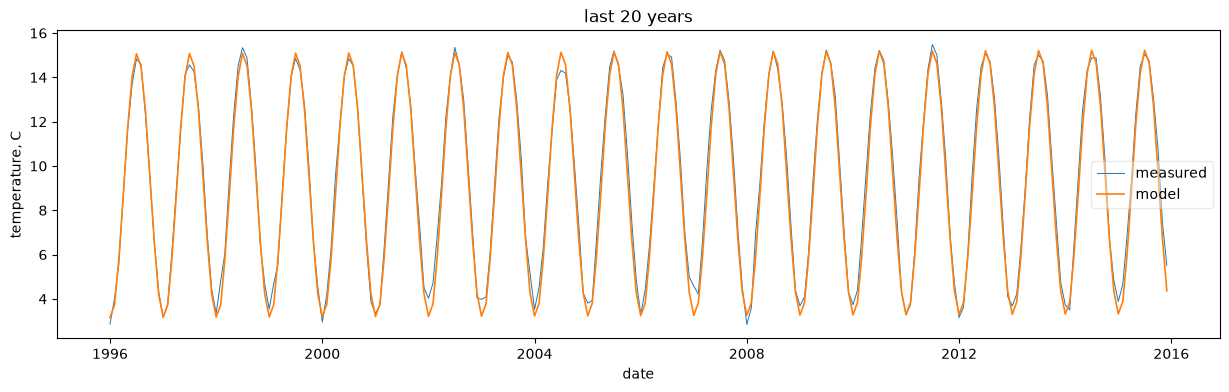

RMSE: 0.4181075834851416


In [10]:
# ========= YOUR CODE STARTS HERE ========= #
A1 = design_matrix(t_month, degree=1)   # month_index defaults correctly here
coeffs1 = solve_reference(A1, y)
fit1 = A1 @ coeffs1
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, fit1, title="degree 1 + seasonality, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit1[-240:], title="last 20 years")
print("RMSE:", RMSE(fit1, y))


### **2.3** Does the seasonal pair earn its place?

Refit with `seasonal=False` and compare the RMSE. Report both numbers and the ratio.
In one sentence: which of the two components of the model carries more of the signal?

*(Keep this number. Core B will recover the same fact from the data without being told
that the period is 12.)*


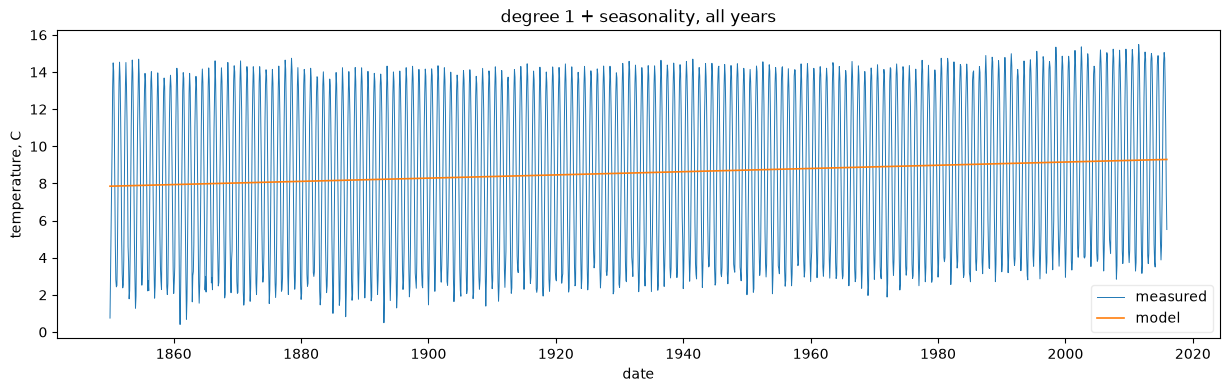

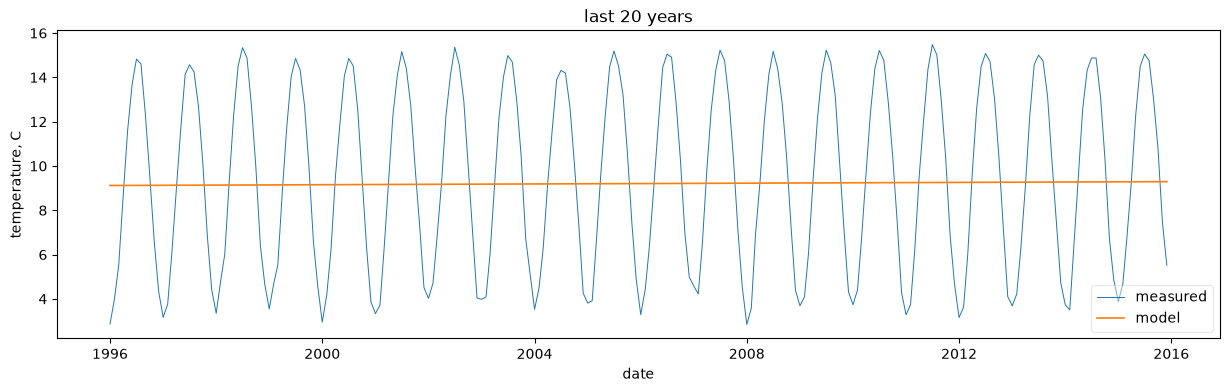

RMSE: 4.241809239973939


In [11]:
# ========= YOUR CODE STARTS HERE ========= #
A2 = design_matrix(t_month, degree=1, seasonal=False)   # month_index defaults correctly here
coeffs2 = solve_reference(A2, y)
fit2 = A2 @ coeffs2

plot_temps(temp_data["date"], y, fit2, title="degree 1 + seasonality, all years")
plot_temps(temp_data["date"][-240:], y[-240:], fit2[-240:], title="last 20 years")
print("RMSE:", RMSE(fit2, y))
# ========== YOUR CODE ENDS HERE ========== #


---
It seems trivial to conclude that the seasonal component is important in this data, because the pattern is easy to read. When we fitted two regressions (with and without the seasonal component), the RMSE of the non-seasonal variant was about 10 times larger than that of the seasonal one (4.2418 / 0.4181). This suggests that the seasonal component carries most of the signal here.

---


---
## 3. Raise the degree until the routes disagree

A degree-1 trend is a strong assumption. The obvious move is to let the polynomial be
more flexible and see whether the fit improves. So sweep the degree and watch what
happens &mdash; not to the fit, but to the *solvers*.


### **3.1** Predict first

Before running anything, write down your prediction. As the degree $d$ grows from 1 to 12,
on the raw month index $t = 0, 1, \dots, 1991$:

1. What will happen to $\operatorname{cond}(A)$? Guess an order of magnitude at $d = 6$.
2. Which solver will fail first, and at roughly which degree?
3. Will the *fitted curves* from the two solvers look different on a plot?

---
1. The condition number is the largest eigenvalue divided by the smallest one, and since the smallest eigenvalue can't exceed the smallest diagonal entry and the largest can't be below the largest diagonal entry, the order of magnitude is at least 1991^6 / 1, about 10^19.
2. The normal equations fails first because of A^T@A, at about degree 3, because it squares the condition number and reaches the double-precision limit of about 10^16, while Householder QR lasts one to two degrees longer, until about degree 5. (1991^n <= 10^16 -> n <= 16 / (log10(1991)) -> n <= 4.84 for QR and n <= 2.42 for normal equation)
3. Curves will be same till the moment normal equation fail on 3rd degree, while QR still will be stable untill it reaches the 5th degree.
---


In [12]:
def sweep(t: np.ndarray, y: np.ndarray, degrees=range(0, 13)) -> pd.DataFrame:
    """For each degree: cond(A), cond(A^T A), and how far each solver is from
    the reference, measured as a relative error in the coefficient vector."""
    rows = []
    for d in degrees:
        A = design_matrix(t, degree=d, month_index=t_month)
        # ========= YOUR CODE STARTS HERE ========= #
        cA    = np.linalg.cond(A)        # cond(A)
        cAtA  = np.linalg.cond(A.T @ A)        # cond(A^T A), computed from the formed matrix
        xr    = solve_reference(A, y) # ref # xn, xq, xr = solve_normal_equation(A, y_), solve_qr(A, y_), solve_reference(A, y_)
        e_ne  = np.linalg.norm(solve_normal_equation(A, y) - xr) / np.linalg.norm(xr)        # ||x_normal - x_ref|| / ||x_ref||
        e_qr  = np.linalg.norm(solve_qr(A, y) - xr) / np.linalg.norm(xr)        # ||x_qr     - x_ref|| / ||x_ref||
        rmse  = RMSE(A @ xr, y)       # RMSE of the reference fit
        # ========== YOUR CODE ENDS HERE ========== #
        rows.append(dict(degree=d, cond_A=cA, cond_AtA=cAtA,
                         err_normal=e_ne, err_qr=e_qr, rmse=rmse))
    return pd.DataFrame(rows).set_index("degree")


raw = sweep(t_month, y)
raw.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                  "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.37e-15,1.22e-15,0.5848
1,2.30e+03,5.28e+06,1.73e-15,9.54e-16,0.4181
2,5.32e+06,2.83e+13,1.29e-14,2.63e-15,0.4031
3,1.19e+10,1.42e+20,1.23e-11,1.22e-11,0.3992
4,2.61e+13,5.50e+25,2.10e+02,2.10e+02,4.5397
5,5.48e+16,1.78e+32,1.06e+05,1.06e+05,5.0220
6,7.61e+20,5.99e+38,7.90e+07,7.90e+07,5.4683
7,1.25e+25,2.06e+45,7.58e+10,7.58e+10,5.8521
8,5.77e+28,7.20e+51,4.86e+17,4.86e+17,6.9231


### **3.2** What actually happened

Compare the table against your prediction, point by point. In particular:

1. At which degree does `err_normal` first exceed $10^{-6}$? At which does `err_qr`?
2. Something has gone wrong that the lecture did **not** predict: $QR$ fails too, and at
   almost the same degree. The $QR$ route never forms $A^{\top}A$, so the
   $\operatorname{cond}(A)^2$ argument does not apply to it. Why is it failing anyway?
3. Look at the last column. Does the RMSE warn you that anything is wrong?

---
1. At degree 4, as well as QR did.
2. We compare QR not with ground truth but with the solution returned by `np.linalg.lstsq`. It has the `rcond` param which by default (and in our lab explicitly) is None. This param means that every singular value with $\sigma_i/\sigma_{\max} < \varepsilon \cdot \max(m,n) \approx 4.4\cdot10^{-13}$ is set to zero and its part of the solution is dropped. At degree 4 the $t^4$ column is so big that the constant, $\cos$ and $\sin$ columns fall below this threshold. So the reference loses the mean and the seasonality, and QR looks wrong the same way as the normal equation.
3. RMSE jumps from 0.3992 to 4.5397 on 4th step and keep growing, what means we zero easier components (smaller degrees) and it's become harder to find least squares without basic components like 0, 1 power and trigonometric functions.
---


### **3.3** Diagnose the design matrix

Print the column norms of $A$ at $d = 6$ on the raw month index. Report the ratio of the
largest to the smallest. Then answer: is the *problem* ill-conditioned, or is this
particular *matrix* badly built? Those are different diagnoses with different cures.


In [13]:
# ========= YOUR CODE STARTS HERE ========= #
A = design_matrix(t_month, degree=6, month_index=t_month)

norms = np.linalg.norm(A, axis=0)
labels = [f"t^{j}" for j in range(7)] + ["sin", "cos"]
for j, (label, n) in enumerate(zip(labels, norms)):
    print(f"col {j} ({label:>3}):      {n:.3e}")

print(f"ratio max to min: {norms.max() / norms.min():.3e}")
print(f"cond(A):          {np.linalg.cond(A):.3e}")
# ========== YOUR CODE ENDS HERE ========== #


col 0 (t^0):      4.463e+01
col 1 (t^1):      5.131e+04
col 2 (t^2):      7.915e+07
col 3 (t^3):      1.332e+11
col 4 (t^4):      2.340e+14
col 5 (t^5):      4.215e+17
col 6 (t^6):      7.721e+20
col 7 (sin):      3.156e+01
col 8 (cos):      3.156e+01
ratio max to min: 2.447e+19
cond(A):          7.607e+20


---

I guess the second (at least because the next "one-line fix" proves this), because by changing them in some way so they don't explode, the model will stay unchanged, but we will be able to keep the equation stable for longer.

---


---
## 4. The one-line fix

The columns $1, t, t^2, \dots, t^{d}$ with $t$ running to $1991$ have wildly different
scales: the last column is of order $10^{19}$ while the first is $1$. Rescale time to the
unit interval, $s = t / (N-1) \in [0, 1]$, and repeat. Nothing about the *model* changes
&mdash; the span of the columns is identical, so the fitted curve is mathematically the same
function. Only the coordinates change.


In [14]:
s = t_month / (N - 1)                      # rescaled time, in [0, 1]

scaled = sweep(s, y)
scaled.style.format({"cond_A": "{:.2e}", "cond_AtA": "{:.2e}",
                     "err_normal": "{:.2e}", "err_qr": "{:.2e}", "rmse": "{:.4f}"})


,cond_A,cond_AtA,err_normal,err_qr,rmse
degree,,,,,
0,1.41e+00,2.00e+00,1.37e-15,1.22e-15,0.5848
1,4.39e+00,1.93e+01,4.46e-15,1.64e-15,0.4181
2,2.29e+01,5.23e+02,1.02e-13,1.86e-15,0.4031
3,1.24e+02,1.55e+04,1.59e-12,6.26e-15,0.3992
4,6.89e+02,4.75e+05,6.20e-12,1.37e-14,0.3951
5,3.86e+03,1.49e+07,6.27e-10,5.38e-14,0.3946
6,2.17e+04,4.73e+08,2.34e-08,7.51e-14,0.3895
7,1.23e+05,1.52e+10,6.13e-08,1.90e-13,0.3878
8,7.00e+05,4.89e+11,1.81e-05,5.08e-13,0.3867


### **4.1** Now the lecture's prediction should hold

1. Plot `err_normal` and `err_qr` against degree on a log scale, for the scaled design.
2. At which degree do the two curves first separate by more than one order of magnitude?
3. The rule of thumb says the normal-equation route loses about
   $\log_{10}\operatorname{cond}(A)^2$ decimal digits, against $\log_{10}\operatorname{cond}(A)$
   for $QR$. Check this against your table at $d = 8$ and $d = 12$: predict the number of
   correct digits from the condition number, then count the digits you actually got.
4. At which degree does $\operatorname{cond}(A^{\top}A)$ exceed $1/\varepsilon_{\mathrm{mach}}$?
   What does that mean for the matrix `A.T @ A` that your first solver just formed?


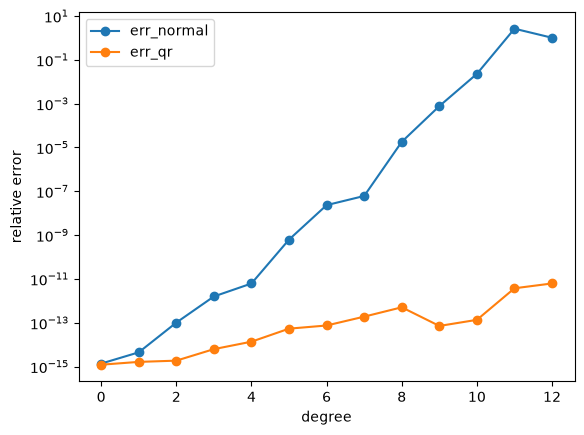

degree the two curves first separate by more than one order of magnitude: 2
d = 11


In [15]:
# ========= YOUR CODE STARTS HERE ========= #
scaled[["err_normal", "err_qr"]].plot(logy=True, marker="o", xlabel="degree", ylabel="relative error")
plt.show()

gap = np.log10(scaled.err_normal / scaled.err_qr).abs()
print(f"degree the two curves first separate by more than one order of magnitude: {gap[gap > 1].index.min()}")

eps = np.finfo(float).eps
d = scaled.loc[[8, 12]]
pd.DataFrame({
    "pred_normal":   -np.log10(eps * d.cond_A**2),
    "actual_normal": -np.log10(d.err_normal),
    "pred_qr":       -np.log10(eps * d.cond_A),
    "actual_qr":     -np.log10(d.err_qr),
}).clip(lower=0).round(1)

eps = np.finfo(float).eps
print(f"d = {scaled[scaled.cond_AtA > 1 / eps].index.min()}")
# ========== YOUR CODE ENDS HERE ========== #


---

2. degree the two curves first separate by more than one order of magnitude: 2
3. in case of normal equation the predicted is close to actual errors, but in case of QR the difference is bigger. the main reason is that we predict the lower bound and real data can have more correct digits, and we also compare QR with the reference instead of the true solution, so errors can be collected on ground truth side.
4. from d = 11 A.T @ A is singular, because rounding errors are bigger than its smallest eigenvalue, so the information is lost before solving even starts.

---


### **4.2** The cost of the fix

Rescaling cost one line and no flops. Ill-conditioning that disappears under a change of
units was never a property of the underlying problem &mdash; it was a property of the
*coordinates you chose to state it in*.

So: is the ill-conditioning you saw in Section 3 real or artificial? Is the residual
ill-conditioning in Section 4 &mdash; which rescaling did **not** remove &mdash; real or artificial?
*Harder &mdash; not required for full marks; we will discuss it at the defence:* say how you
would tell the two apart in general, for a problem where you cannot see the answer.

---
\### **YOUR ANSWER HERE** \###

---


---
## 5. Coefficients and predictions are not equally hard

At $d = 12$ on the scaled design, solve the problem both ways and compare **two** things:
the coefficient vectors, and the fitted curves.


x_ne: [ 8.1628e+00 -1.4048e+01  3.6776e+02 -3.7692e+03  2.0504e+04 -6.6674e+04
  1.3483e+05 -1.6276e+05  9.0414e+04  2.9380e+04 -7.9514e+04  4.7113e+04
 -9.8831e+03 -5.9508e+00 -4.7266e-01]
x_qr: [ 8.1258e+00 -8.3499e+00  1.5285e+02 -2.5607e+02 -1.0573e+04  9.9813e+04
 -4.4002e+05  1.1586e+06 -1.9520e+06  2.1270e+06 -1.4518e+06  5.6466e+05
 -9.5512e+04 -5.9508e+00 -4.7265e-01]
coefficients: 1.02e+00
predictions:  6.77e-04
rmse normal:  0.386569
rmse qr:      0.386515


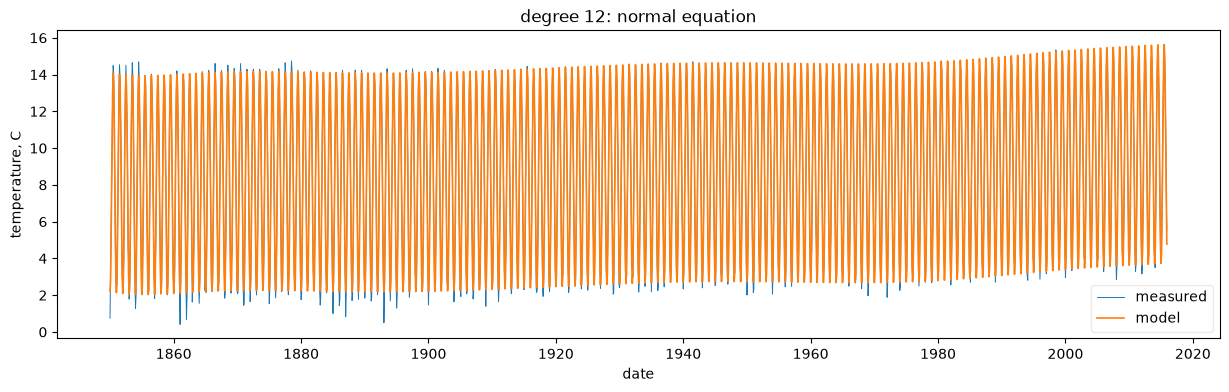

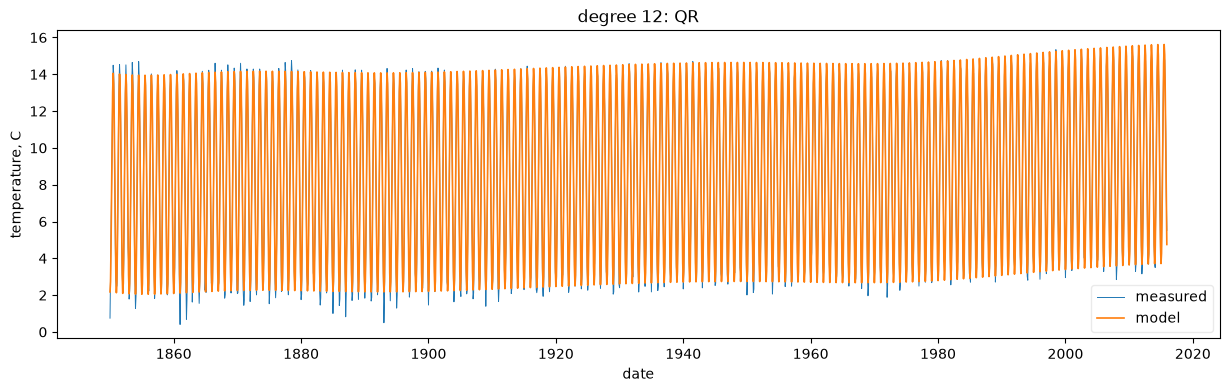

In [16]:
d = 12
A = design_matrix(s, degree=d, month_index=t_month)

# ========= YOUR CODE STARTS HERE ========= #
x_ne  = solve_normal_equation(A, y)
x_qr  = solve_qr(A, y)

print(f"x_ne: {x_ne}\nx_qr: {x_qr}")

# relative difference in the coefficients
# relative difference in the predictions A @ x
coef_diff = np.linalg.norm(x_ne - x_qr) / np.linalg.norm(x_qr)
pred_diff = np.linalg.norm(A @ (x_ne - x_qr)) / np.linalg.norm(A @ x_qr)
print(f"coefficients: {coef_diff:.2e}\npredictions:  {pred_diff:.2e}")
print(f"rmse normal:  {RMSE(A @ x_ne, y):.6f}\nrmse qr:      {RMSE(A @ x_qr, y):.6f}")
# ========== YOUR CODE ENDS HERE ========== #

plot_temps(temp_data["date"], y, A @ x_ne, title=f"degree {d}: normal equation")
plot_temps(temp_data["date"], y, A @ x_qr, title=f"degree {d}: QR")


### **5.1**

One of the two comparisons exposes the damage and the other hides it. Which, by how many
orders of magnitude, and **why**?

Then the consequence, in one paragraph: if you had judged these two fits by plotting them,
or by their RMSE, what would you have concluded? Name one situation in data science where
you need the coefficients themselves and not just the predictions &mdash; and one where the
predictions are genuinely all you need.

---
The coefficients differ by 1.02, while the predictions differ by just 6.77e-04, about 3 orders of magnitude less. This happens because the high-degree columns have almost the same shape, so in simple words they are interchangeable, and that's exactly what happens here. If we had only looked at the RMSE, we could not have understood that something went wrong, but we commonly use coefficients to interpret the results and find patterns, and when they are numerically wrong, the conclusions can be wrong as well.

---


---
## 6. Summary

Answer in a few sentences each. These are the questions the defence will start from.

1. You implemented one piece of mathematics two ways and they disagreed. State precisely
   what the disagreement was caused by, and which of the two answers was right.
2. Given a new least squares problem tomorrow, what would you compute *before* choosing a
   solver, and what would you do with the number?
3. What is the largest $\operatorname{cond}(A)$ at which you would still trust the normal
   equation in double precision, and where does your threshold come from?
4. Which degree of trend would you actually report for this series, and on what grounds?
   Note that this is a modelling question, not a numerical one &mdash; the numerically safest
   fit is not automatically the one to publish.

---
1. The disagreement came from floating-point precision, i.e. the rounding of numbers while performing the formulas, because in case of the normal equation we have to form A.T @ A, and this is the place where the condition number gets squared, so the rounding errors are amplified by cond(A)^2 instead of cond(A). QR never forms A.T @ A, so it's result are more stable.
2. I would compute the condition number of A (after scaling the columns, otherwise it can be huge just because of units) to understand how many digits I can lose, which is about log10(cond) for QR and twice as many for the normal equation. If even QR loses too many digits, I would rescale t or change the basis instead of changing the solver. In practice I would almost always use QR.
3. I can trust it while cond(A) squared is still smaller than 1 / eps, which is about 4.5e15, so cond(A) should be smaller than about 1e8. The threshold comes from the precision of float64, where eps is about 2.2e-16, so we have only about 16 correct digits, and the normal equation loses twice log10(cond) of them. At this limit no correct digits are left, so for useful results cond(A) should be much smaller, e.g. about 1e4 to keep 8 digits.
4. I would use the elbow rule for the RMSE, which is also commonly used in unsupervised ML (k-means) or PCA, because the solution with the smallest error is usually not the best one due to overfitting (especially since we use this fit to explain the current data, not to predict new data). The fewer parameters a model has, the fewer places there are for something to go wrong, and more parameters don't bring a big improvement. The RMSE drops from 0.585 to 0.403 up to degree 2, and after that only to 0.387 at degree 12. So I would stop at degree 2-3, it's safe and easy, and everything after that just tries to catch patterns in the noise.
---

---
---
# $\star$ Extensions (bonus)

> **Optional. Up to 1 bonus point for the whole lab.** Attempt **at most one** of the three
> extensions &mdash; Extensions 1 and 2 are below, Extension 3 is at the end of Core B. A
> second extension earns nothing, and a shallow attempt at one earns nothing either: the
> point is for a **finding you can defend**, not for code that ran. Say in your `README`
> which one you chose.

Everything above this line is Core A and is marked in full without these.


---
## $\star$ Extension 1 (bonus): Weighted least squares on the full record

Ordinary least squares treats every observation as equally trustworthy. This series is
not: every month comes with a 95% uncertainty half-width $\sigma_j$, which is large in the
18th century and small today. Weighted least squares minimises
$$ \sum_j w_j\,\big(y_j - (A\mathbf{x})_j\big)^2, \qquad w_j = 1/\sigma_j^2, $$
whose solution satisfies $A^{\top}WA\,\hat{\mathbf{x}} = A^{\top}W\mathbf{y}$ with
$W = \operatorname{diag}(w_j)$.

The data file for this extension is supplied: `land-temp-1750-2015-with-uncertainty.csv`,
with columns `date`, `avg_temp` and `uncertainty`, 3192 months from January 1750. It is
the same Berkeley Earth series as the core file, extended back a century and with the
uncertainty column added; from 1850 on, `avg_temp` is identical to the core file. The
twelve missing months are left in, as blanks.

1. Load the file. Report which months are missing. **Build the month index on the full
   3192-month grid before you drop anything**, then drop the missing rows. Explain why
   dropping rows is acceptable here when it was not acceptable in Core B &mdash; and what
   would go wrong if you built the month index *after* dropping.
2. Plot $\sigma_j$ against time on a log scale. When does it first fall below 0.2 C? What
   fraction of the total weight $\sum w_j$ do the 1750-1849 months carry, compared with
   their fraction of the rows?
3. Reduce weighted least squares to an **ordinary** one by rescaling each row of $A$ and
   $\mathbf{y}$ by $1/\sigma_j$, so that your `solve_qr` does the work unchanged. Show
   that the rescaled problem has the weighted normal equation above.
4. Measure time in **centuries from 1950**, $u = (\text{year} - 1950)/100$, for every fit
   below. (Rescaling by $N-1$ as in section 4 would put fits of different lengths in
   different units, and their coefficients could not be compared.) Fit a trend of
   degree 1 plus seasonality four ways &mdash; OLS and WLS, each on 1850-2015 and on
   1750-2015 &mdash; and tabulate the slope in C per century.
5. Repeat with a trend of degree 2, and report the slope **at 1950**, which is the
   coefficient of $u$.
6. The finding. Did adding the 18th century change the OLS trend, and in which
   direction? Did weighting undo that? Why does WLS change the answer even on 1850-2015,
   where no early data is involved? And why do the four estimates agree much better at
   degree 2 than at degree 1? One idea explains all four.


In [17]:
EXT_DATA_FILE = "land-temp-1750-2015-with-uncertainty.csv"   # supplied with the lab

# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---


---
## $\star$ Extension 2 (bonus): Minimum-norm and ridge on a rank-deficient design

Every design matrix so far had independent columns, so the least squares solution was
unique. Break that on purpose.

1. Take the scaled degree-2 design from section 4 and append one column that is an **exact**
   linear combination of two others &mdash; e.g. the sum of the $s$ and $s^2$ columns. Confirm
   with `np.linalg.matrix_rank` that the rank did not go up.
2. Explain why the normal equation now has infinitely many solutions, and what happens if
   you call your `solve_normal_equation` on it anyway.
3. `np.linalg.lstsq` still returns one answer. Which one, out of the infinitely many? Verify
   your claim numerically &mdash; compare with `np.linalg.pinv(A) @ y`.
4. Ridge regression solves $(A^{\top}A + \lambda I)\,\mathbf{x} = A^{\top}\mathbf{y}$, which
   is uniquely solvable for every $\lambda > 0$. Compute it for
   $\lambda = 10^{-1}, 10^{-2}, \dots, 10^{-10}$ and plot
   $\|\mathbf{x}_\lambda - \mathbf{x}_{\mathrm{lstsq}}\|$ against $\lambda$ on log-log axes.
5. The finding: the curve should fall and then **turn back up**. Explain both halves. What
   limit is ridge approaching, and what stops it getting there in floating point?


In [18]:
# ========= YOUR CODE STARTS HERE ========= #

# ========== YOUR CODE ENDS HERE ========== #


---
\### **YOUR FINDING HERE** \###

---
